Attrition Prediction

In [561]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [562]:
df = pd.read_csv('HR-Employee-Attrition.csv')

In [563]:
df.shape

(1470, 35)

In [564]:
df.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [565]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [566]:
df.isnull().any()

Age                         False
Attrition                   False
BusinessTravel              False
DailyRate                   False
Department                  False
DistanceFromHome            False
Education                   False
EducationField              False
EmployeeCount               False
EmployeeNumber              False
EnvironmentSatisfaction     False
Gender                      False
HourlyRate                  False
JobInvolvement              False
JobLevel                    False
JobRole                     False
JobSatisfaction             False
MaritalStatus               False
MonthlyIncome               False
MonthlyRate                 False
NumCompaniesWorked          False
Over18                      False
OverTime                    False
PercentSalaryHike           False
PerformanceRating           False
RelationshipSatisfaction    False
StandardHours               False
StockOptionLevel            False
TotalWorkingYears           False
TrainingTimesL

In [567]:
df.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [568]:
X = df[['Age','DailyRate','Gender','Department','Education','EducationField','TotalWorkingYears','YearsAtCompany','YearsSinceLastPromotion']]
y=df['Attrition']

In [569]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=55)

In [570]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
cat_features=X.select_dtypes(include='object').columns
num_features=X.select_dtypes(exclude='object').columns



preprocessor= ColumnTransformer(
    [('num',StandardScaler(),num_features),
    ('cat',OneHotEncoder(drop= 'first'),cat_features)
    ]
)

In [571]:
df['Attrition'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1470 entries, 0 to 1469
Series name: Attrition
Non-Null Count  Dtype 
--------------  ----- 
1470 non-null   object
dtypes: object(1)
memory usage: 11.6+ KB


In [572]:
X_train = preprocessor.fit_transform(X_train)


In [573]:
pd.DataFrame(X_train)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,-0.875175,1.170945,0.094021,-0.691204,-0.652796,-0.360692,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1,-0.875175,-1.144487,-1.860472,-1.327611,-0.975121,-0.669985,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,-0.327125,0.857578,-0.883226,0.454329,1.281158,0.567188,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,-0.875175,-1.661791,-1.860472,-0.563922,-0.008144,-0.360692,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,-0.655955,-0.301381,0.094021,0.199766,-0.008144,-0.360692,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1024,-0.107906,-0.957959,0.094021,-0.182078,0.153019,-0.669985,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1025,-0.107906,-0.510292,0.094021,0.708892,1.281158,1.185775,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1026,0.549754,-0.639618,0.094021,1.472581,2.086972,0.567188,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1027,-1.642444,-0.485422,-1.860472,-0.945767,-0.652796,-0.669985,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


In [574]:
X_test=preprocessor.transform(X_test)

In [575]:
#from sklearn.linear_model import LogisticRegressionCV
#logistic=LogisticRegressionCV()
#logistic.fit(X_train,y_train)

In [576]:
#y_pred=logistic.predict(X_test)

In [580]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

def train_model(X_train,X_test,y_train,y_test):      
    
    models = {
        "Logistic Regression": LogisticRegression(),
        "Decision Tree": DecisionTreeClassifier(),
        "Random Forest": RandomForestClassifier(),
        "Gradient Boosting": GradientBoostingClassifier(),
        "AdaBoost": AdaBoostClassifier(),
    }

    params={
            "Decision Tree": {
                'criterion':['gini', 'entropy', 'log_loss'],
                # 'splitter':['best','random'],
                # 'max_features':['sqrt','log2'],
            },
            "Random Forest":{
                # 'criterion':['gini', 'entropy', 'log_loss'],
                
                # 'max_features':['sqrt','log2',None],
                'n_estimators': [8,16,32,128,256]
            },
            "Gradient Boosting":{
                # 'loss':['log_loss', 'exponential'],
                'learning_rate':[.1,.01,.05,.001],
                'subsample':[0.6,0.7,0.75,0.85,0.9],
                # 'criterion':['squared_error', 'friedman_mse'],
                # 'max_features':['auto','sqrt','log2'],
                'n_estimators': [8,16,32,64,128,256]
            },
            "Logistic Regression":{},
            "AdaBoost":{
                'learning_rate':[.1,.01,.001],
                'n_estimators': [8,16,32,64,128,256]
            }
    }

    return models,params

def evaluate_models(X_train,X_test,y_train,y_test,models,params):
    report={}
    for i in range(len(list(models))):
        model = list(models.values())[i]
        para = params[list(models.keys())[i]]

        gs = GridSearchCV(model,para,cv=3)
        gs.fit(X_train,y_train)

        model.set_params(**gs.best_params_)
        model.fit(X_train,y_train)
        y_train_pred = model.predict(X_train)

        y_test_pred = model.predict(X_test)
        train_model_score = accuracy_score(y_train, y_train_pred)
        test_model_score = accuracy_score(y_test, y_test_pred)


        report[list(models.keys())[i]] = test_model_score
    
    return report

models, params = train_model(X_train, X_test, y_train, y_test)    
model_report:dict= evaluate_models(X_train=X_train,X_test=X_test,y_train=y_train,y_test=y_test,params=params,models=models)

print(model_report)




{'Logistic Regression': 0.8571428571428571, 'Decision Tree': 0.7142857142857143, 'Random Forest': 0.8571428571428571, 'Gradient Boosting': 0.8594104308390023, 'AdaBoost': 0.8594104308390023}


from sklearn.ensemble import RandomForestClassifier
model= RandomForestClassifier(
    n_estimators=200,
    random_state=55,
    class_weight='balanced'
)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

<Axes: xlabel='count', ylabel='Attrition'>

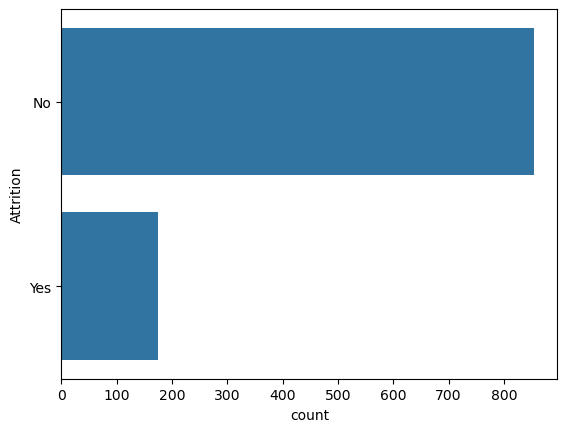

In [578]:
import seaborn as sns
sns.countplot(y_train)

In [579]:
sns.countplot(y_test_pred)

NameError: name 'y_test_pred' is not defined

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_test_pred))
print(confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

Accuracy: 0.8253968253968254
[[354  25]
 [ 52  10]]
              precision    recall  f1-score   support

          No       0.87      0.93      0.90       379
         Yes       0.29      0.16      0.21        62

    accuracy                           0.83       441
   macro avg       0.58      0.55      0.55       441
weighted avg       0.79      0.83      0.80       441

